# 3. Topic Modeling sur les Avis d'Assurance

 Ce notebook applique l'algorithme LDA pour identifier automatiquement les
       grands thèmes abordés dans les avis clients d'assurance.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyLDAvis.gensim_models
import seaborn as sns
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.utils import simple_preprocess
from transformers import pipeline as hf_pipeline

from app.utils.spinner import run_with_spinner
from config import *

## 3.1 Chargement des données nettoyées

In [2]:
df = pd.read_csv(DATA_CLEAN)

## 3.2 Préparation du corpus pour LDA

In [3]:
def tokenize_for_lda(text):
    """Tokenise le texte déjà nettoyé pour LDA."""
    if pd.isna(text):
        return []
    return [t for t in simple_preprocess(str(text), deacc=True) if len(t) > 2]

In [4]:
texts = run_with_spinner(
    lambda: df[CLEAN_COL].apply(tokenize_for_lda).tolist(),
    msg="Tokenisation..."
)
print(f"Tokenisation terminée !")

Tokenisation terminée !


In [5]:
all_words = [w for doc in texts for w in doc]
print(f"Tokens totaux       : {len(all_words)}")
print(f"Vocabulaire unique  : {len(set(all_words))}")
print(f"Tokens moy/document : {len(all_words) / len(texts):.1f}")

Tokens totaux       : 515749
Vocabulaire unique  : 14048
Tokens moy/document : 21.4


In [6]:
dictionary = corpora.Dictionary(texts)
print(f"Dictionnaire avant filtrage : {len(dictionary)} mots")

dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Dictionnaire après filtrage : {len(dictionary)} mots")

corpus_bow = [dictionary.doc2bow(text) for text in texts]
print(f"Corpus : {len(corpus_bow)} documents")

Dictionnaire avant filtrage : 14048 mots
Dictionnaire après filtrage : 4875 mots
Corpus : 24100 documents


In [7]:
# Exemple
print(f"Document 0 (5 premiers) :")
print([(dictionary[id_], freq) for id_, freq in corpus_bow[0][:5]])

Document 0 (5 premiers) :
[('assurance', 1), ('bien', 1), ('clair', 1), ('contacter', 1), ('expliquer', 1)]


## 3.3 Entraînement du modèle LDA

In [8]:
NUM_TOPICS = 6

lda_model = run_with_spinner(
    lambda: LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        random_state=42,
        passes=10,
        iterations=400,
        alpha='auto',
        eta='auto',
        per_word_topics=True,
    ),
    msg=f"Entraînement LDA (num_topics={NUM_TOPICS})..."
)
print("Entraînement terminé !")

Entraînement terminé !


In [9]:
print("Top 10 mots par topic")
for i, topic in lda_model.print_topics(num_topics=NUM_TOPICS, num_words=10):
    print(f"Topic {i}: {topic}")
    print()

Top 10 mots par topic
Topic 0: 0.087*"mutuel" + 0.039*"remboursement" + 0.028*"carte" + 0.024*"sante" + 0.020*"rembourser" + 0.010*"vert" + 0.010*"demande" + 0.010*"soin" + 0.010*"adherent" + 0.009*"pas"

Topic 1: 0.046*"repondre" + 0.031*"personn" + 0.028*"telephone" + 0.026*"conseiller" + 0.023*"reponse" + 0.022*"question" + 0.020*"joindre" + 0.015*"attente" + 0.015*"rappeler" + 0.014*"impossible"

Topic 2: 0.034*"pas" + 0.030*"mois" + 0.016*"jour" + 0.015*"dossier" + 0.015*"envoyer" + 0.014*"faire" + 0.014*"recevoir" + 0.012*"demande" + 0.012*"contrat" + 0.012*"document"

Topic 3: 0.054*"service" + 0.045*"prix" + 0.036*"assurance" + 0.029*"bon" + 0.024*"satisfait" + 0.022*"bien" + 0.021*"tarif" + 0.020*"client" + 0.019*"satisfaire" + 0.019*"rapide"

Topic 4: 0.052*"charge" + 0.044*"expert" + 0.026*"suite" + 0.022*"prise" + 0.019*"pris" + 0.019*"degat" + 0.017*"indemnisation" + 0.017*"juridique" + 0.016*"arret" + 0.014*"protection"

Topic 5: 0.068*"pas" + 0.038*"assurance" + 0.023*"s

## 3.4 Identification des topics

In [10]:
TOPIC_LABELS = {
    0: 'Sinistres Auto',
    1: 'Problèmes & Litiges',
    2: 'Tarifs & Contrats',
    3: 'Assurance Santé',
    4: 'Prise en Charge',
    5: 'Satisfaction Client',
}

In [11]:
print("=== Analyse des topics ===\n")
for topic_id in range(NUM_TOPICS):
    words = lda_model.show_topic(topic_id, topn=10)
    word_str = ', '.join([f"{w}({s:.3f})" for w, s in words])
    print(f"Topic {topic_id} → {TOPIC_LABELS[topic_id]}")
    print(f"  {word_str}\n")

=== Analyse des topics ===

Topic 0 → Sinistres Auto
  mutuel(0.087), remboursement(0.039), carte(0.028), sante(0.024), rembourser(0.020), vert(0.010), demande(0.010), soin(0.010), adherent(0.010), pas(0.009)

Topic 1 → Problèmes & Litiges
  repondre(0.046), personn(0.031), telephone(0.028), conseiller(0.026), reponse(0.023), question(0.022), joindre(0.020), attente(0.015), rappeler(0.015), impossible(0.014)

Topic 2 → Tarifs & Contrats
  pas(0.034), mois(0.030), jour(0.016), dossier(0.015), envoyer(0.015), faire(0.014), recevoir(0.014), demande(0.012), contrat(0.012), document(0.012)

Topic 3 → Assurance Santé
  service(0.054), prix(0.045), assurance(0.036), bon(0.029), satisfait(0.024), bien(0.022), tarif(0.021), client(0.020), satisfaire(0.019), rapide(0.019)

Topic 4 → Prise en Charge
  charge(0.052), expert(0.044), suite(0.026), prise(0.022), pris(0.019), degat(0.019), indemnisation(0.017), juridique(0.017), arret(0.016), protection(0.014)

Topic 5 → Satisfaction Client
  pas(0.06

## 3.5 Cohérence du modèle

In [12]:
cv_score = run_with_spinner(
    lambda: CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    ).get_coherence(),
    msg="Calcul du score de cohérence C_V..."
)
print(f"Score de cohérence C_V : {cv_score:.4f}")

Score de cohérence C_V : 0.5426


In [13]:
def search_coherence():
    values = []
    for n in n_range:
        m = LdaModel(corpus=corpus_bow, id2word=dictionary,
                     num_topics=n, random_state=42, passes=5, iterations=100)
        cm = CoherenceModel(model=m, texts=texts, dictionary=dictionary, coherence='c_v')
        values.append(cm.get_coherence())
    return values

In [14]:
n_range = list(range(2, 13, 2))

coherence_values = run_with_spinner(
    search_coherence,
    msg=f"Recherche du nombre optimal de topics {n_range}..."
)
print(f"Recherche du nombre optimal de topics terminée !")

Recherche du nombre optimal de topics terminée !


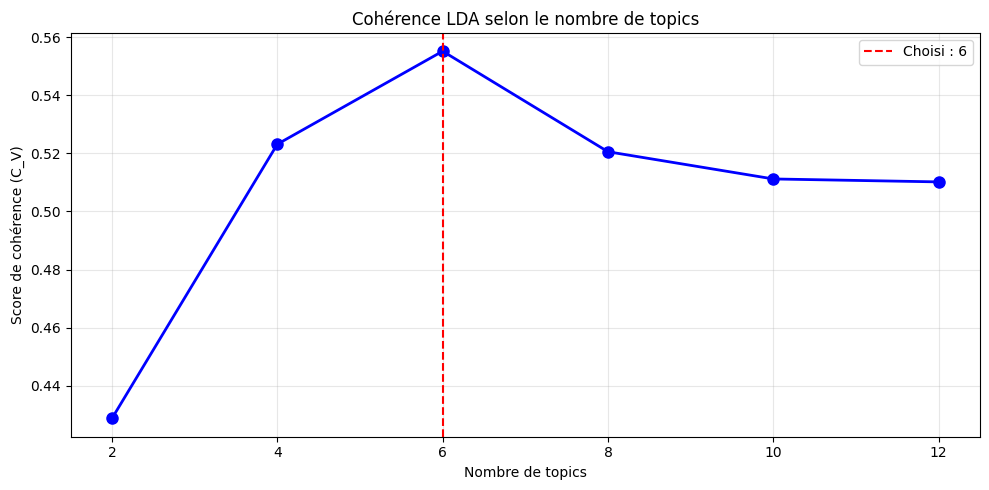

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(n_range, coherence_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=NUM_TOPICS, color='r', linestyle='--', label=f'Choisi : {NUM_TOPICS}')
plt.xlabel('Nombre de topics')
plt.ylabel('Score de cohérence (C_V)')
plt.title('Cohérence LDA selon le nombre de topics')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.6 Visualisation pyLDAvis

In [16]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_model, corpus_bow, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, str(LDA_VIZ_PATH))
print(f"{LDA_VIZ_PATH}")
pyLDAvis.display(vis)

/Users/amaitre/prive/4_ECOLE/S8/NLP/sentiment_analysis_model/models/lda/lda_visualization.html


## 3.7 Attribution des topics aux reviews

In [17]:
def get_dominant_topic(bow):
    probs = lda_model.get_document_topics(bow)
    if not probs:
        return 0, 0.0
    top = max(probs, key=lambda x: x[1])
    return top[0], float(top[1])

In [18]:
assignments = [get_dominant_topic(bow) for bow in corpus_bow]
df['topic_id'] = [a[0] for a in assignments]
df['topic_prob'] = [a[1] for a in assignments]
df['topic_label'] = df['topic_id'].map(TOPIC_LABELS)

In [19]:
print("Distribution des topics :")
print(df['topic_label'].value_counts())

Distribution des topics :
topic_label
Assurance Santé        10496
Satisfaction Client     8243
Tarifs & Contrats       4513
Problèmes & Litiges      438
Prise en Charge          259
Sinistres Auto           151
Name: count, dtype: int64


In [20]:
print(f"total : {len(df)}")

total : 24100


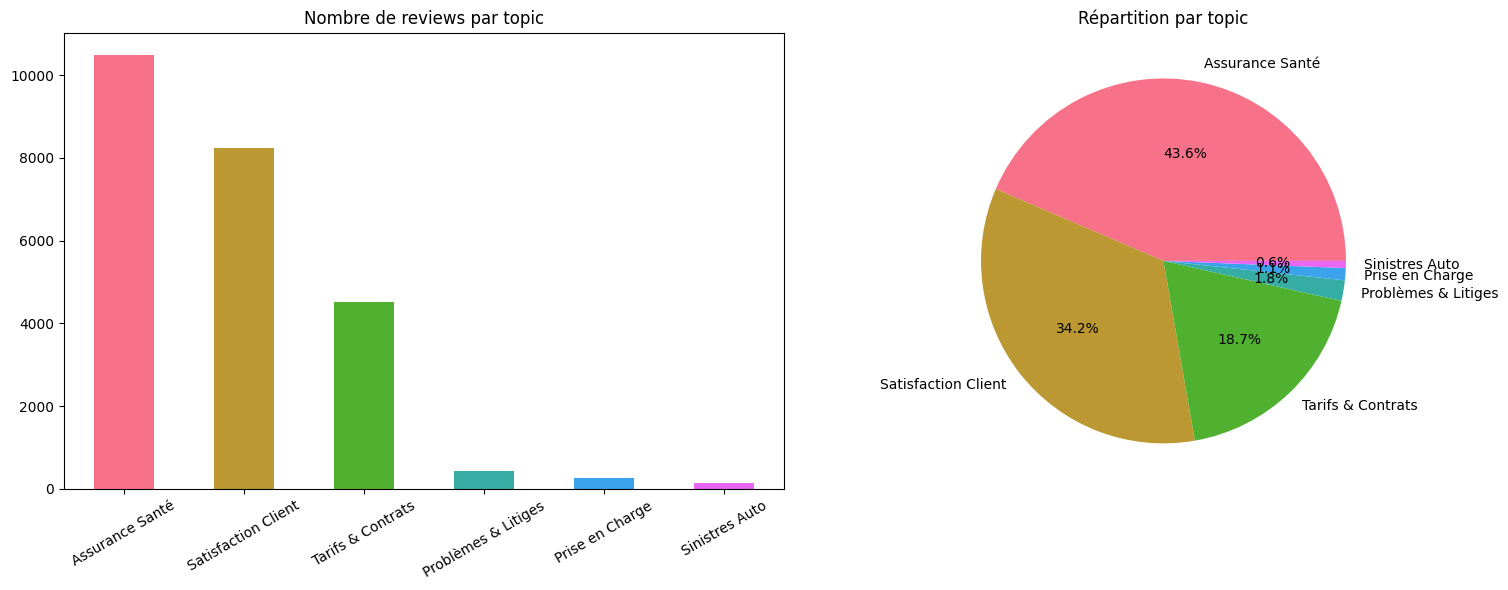

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette('husl', NUM_TOPICS)

topic_counts = df['topic_label'].value_counts()
topic_counts.plot(kind='bar', ax=axes[0], color=palette)
axes[0].set_title('Nombre de reviews par topic')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%', colors=palette)
axes[1].set_title('Répartition par topic')
plt.tight_layout()
plt.show()

In [22]:
print("Exemples de reviews par topic")
for tid, label in TOPIC_LABELS.items():
    reviews = df[df['topic_id'] == tid][TEXT_COL].dropna()
    print('=' * 55)
    print(f"Topic {tid}: {label}  ({len(reviews)} reviews)")
    print('=' * 55)
    for i, r in enumerate(reviews.head(2), 1):
        print(f"  [{i}] {str(r)[:200]}...")

Exemples de reviews par topic
Topic 0: Sinistres Auto  (151 reviews)
  [1] Une très bonne mutuelle qui m'a remboursé très rapidement les dépassement du chirurgien. ...
  [2] Mon Bearded Collie a une une diarrhée pendant près de 7 jours. J'ai consulté à la clinique vétérinaire près de chez moi. Résultat près de 110 € pour une consultation et 2 traitements.
Quelle ne fut pa...
Topic 1: Problèmes & Litiges  (438 reviews)
  [1] franchement, je ne sais comment qualifier cette mutuelle, des delais de traitements plus que long 20 jours pour un remboursement !!!!!! personne ne répond par email, quand on appelle on a plusieurs ve...
  [2] Contact très agréable au téléphone avec une dame très avenante et douce. Elle a répondue à toute nos questions. La prise en charge à l’hôpital était parfaite. Nos sommes rassurés. ...
Topic 2: Tarifs & Contrats  (4513 reviews)
  [1] Voilà 3 mois que la GMF me fait attendre pour un dégât des eaux. J'ai plusieurs contrats chez eux, mais plus pour longtemps ...
 

## 3.8 Analyse croisée topics × étoiles

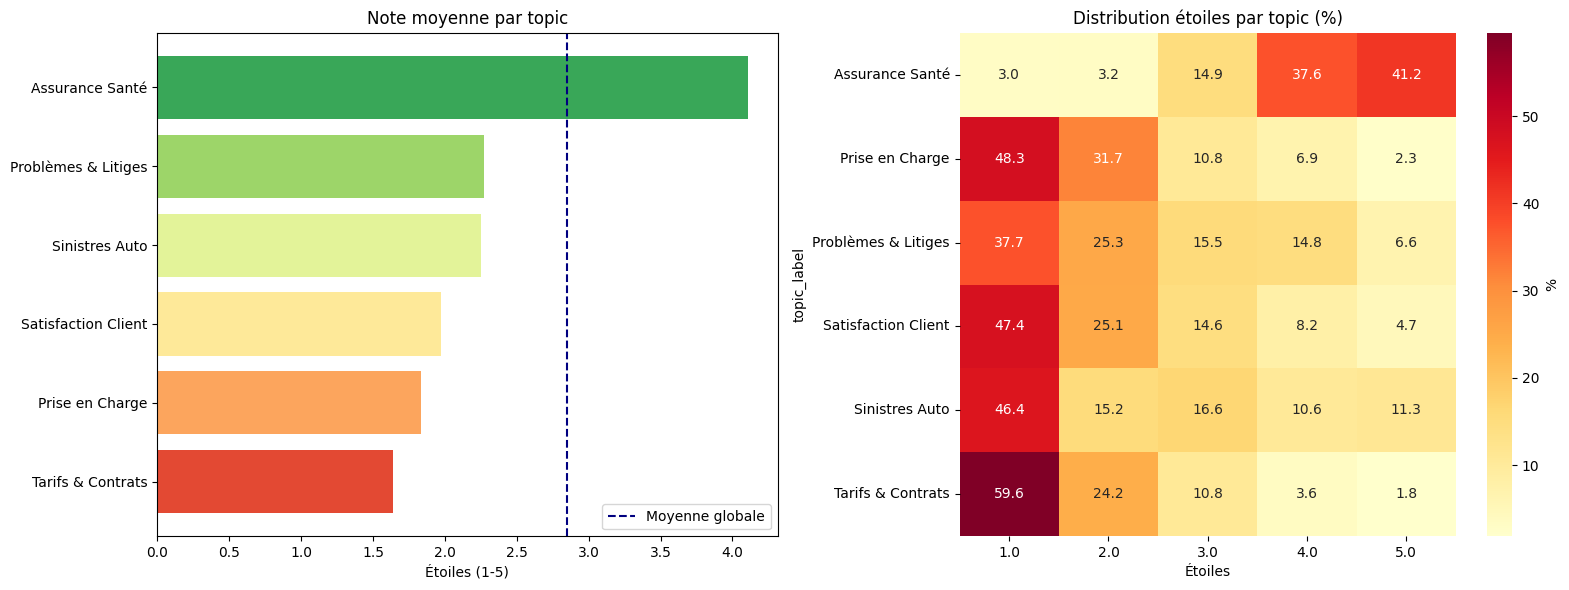

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avg_stars = df.groupby('topic_label')[RATING_COL].mean().sort_values()
colors = sns.color_palette('RdYlGn', len(avg_stars))
axes[0].barh(avg_stars.index, avg_stars.values, color=colors)
axes[0].axvline(df[RATING_COL].mean(), color='navy', linestyle='--', label='Moyenne globale')
axes[0].set_title('Note moyenne par topic')
axes[0].set_xlabel('Étoiles (1-5)')
axes[0].legend()

pivot = df.groupby(['topic_label', RATING_COL]).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': '%'})
axes[1].set_title('Distribution étoiles par topic (%)')
axes[1].set_xlabel('Étoiles')
plt.tight_layout()
plt.show()


## 3.9 Sauvegarde

In [24]:
lda_model.save(str(LDA_MODELS_DIR))
dictionary.save(str(DICTIONARIES_DIR))

In [25]:
df.to_csv(str(DATA_PROCESSED / 'reviews_topics.csv'), index=False)

## 3.10 Analyse de la distribution des probabilités de topic

On examine ici la distribution des probabilités d'appartenance au topic dominant pour chaque document.
Un score élevé indique que le document est fortement associé à un seul topic (thème clair),
tandis qu'un score faible indique un document ambigu appartenant à plusieurs topics à la fois.

On analyse également les documents dits "mixtes" — ceux dont la probabilité du topic dominant
est inférieure à 0.4 — pour comprendre s'ils forment des thèmes de transition ou simplement
des avis généralistes.

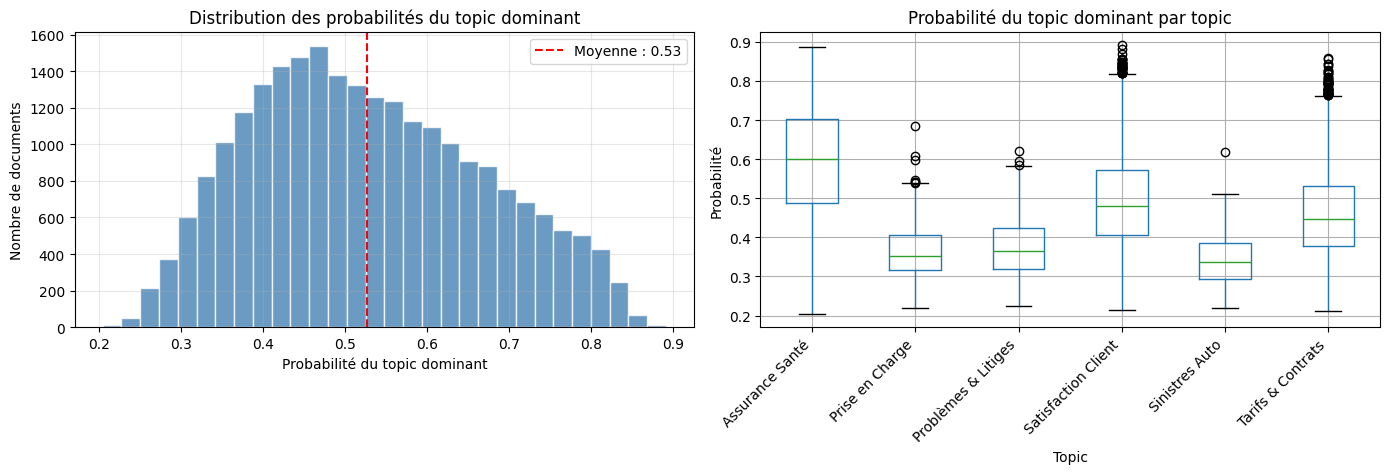

Documents ambigus (topic_prob < 0.4) : 4957 (20.6%)
Documents clairement assignés (topic_prob >= 0.4) : 19143 (79.4%)
Stats sur topic_prob :
count    24100.0000
mean         0.5272
std          0.1405
min          0.2044
25%          0.4179
50%          0.5130
75%          0.6301
max          0.8914
Name: topic_prob, dtype: float64


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global de topic_prob
axes[0].hist(df['topic_prob'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=df['topic_prob'].mean(), color='red', linestyle='--',
                label=f"Moyenne : {df['topic_prob'].mean():.2f}")
axes[0].set_title('Distribution des probabilités du topic dominant')
axes[0].set_xlabel('Probabilité du topic dominant')
axes[0].set_ylabel('Nombre de documents')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot par topic
df.boxplot(column='topic_prob', by='topic_label', ax=axes[1])
axes[1].set_title('Probabilité du topic dominant par topic')
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Probabilité')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Documents "mixtes" (faible certitude d'appartenance à un topic)
threshold = 0.4
mixed_docs = df[df['topic_prob'] < threshold]
print(f"Documents ambigus (topic_prob < {threshold}) : {len(mixed_docs)} ({len(mixed_docs) / len(df) * 100:.1f}%)")
print(
    f"Documents clairement assignés (topic_prob >= {threshold}) : {len(df) - len(mixed_docs)} ({(len(df) - len(mixed_docs)) / len(df) * 100:.1f}%)")

print(f"Stats sur topic_prob :")
print(df['topic_prob'].describe().round(4))